In [1]:
### STEP 1:IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
import re
from PIL import Image


os.chdir("C:/Users/darto/Documents/William/Cornell/Project/Spatial_Registration/Proj02/MPI_Registration")

# Diretórios de saída
out_dir = 'results/py_output/'
r_dir   = 'results/r_output/'
desi_dir = 'results/desi_output/'


# Número de features que pretende usar (ajuste conforme o experimento)
n_features = 16

### Reference landmarks refer to Visium landmarks
### Query landmarks refer to DESI landmarks

# Read images and landmarks
# === Carrega os landmarks do Visium ===
query_landmarks = pd.read_csv(r_dir + 'Query_Reference_Landmarks_for_Visium_Data.csv', index_col=[0, 1])

# Conversão de nomes para compatibilizar com DESI
convert_ids = pd.read_csv(r_dir + "convert_IDs.csv")

# Merge IDs
#query_landmarks = pd.merge(query_landmarks, convert_ids, on='sample_ID', how='left')
query_landmarks = pd.merge(query_landmarks, convert_ids, on='sample_ID', how='left')
query_landmarks = query_landmarks.sort_values(['desi','Coordinates'])


# Lista de amostras e imagens
paths = query_landmarks.sample_ID.unique().tolist()
samples = query_landmarks.desi.unique().tolist()

# === Lê imagens referentes ao Visium ===
#query_images = [cv2.imread(os.path.join(out_dir, path + "_hires_region.png")) for path in paths]
query_images = [cv2.imread(os.path.join('C:/Users/darto/Documents/William/Cornell/Project/Spatial_Registration/Proj02/MPI_Registration/results/plots', path + "_hires_image.png")) for path in paths]


# === Lê arquivos do diretório DESI ===
arr = os.listdir(desi_dir)
reference_files = [file for file in arr if re.search("pos|neg1|neg2",file)]

# === Lê os landmarks de referência do DESI ===
reference_landmarks = pd.read_csv(os.path.join(r_dir, 'Query_Reference_Landmarks_for_DESI_Data.csv'), index_col=[0, 1])
reference_landmarks = reference_landmarks.sort_values(["sample_ID","charge"])

# Função auxiliar para listar apenas itens únicos (sem repetição)
# Prin t unique image files of DESI Data
from functools import reduce
def unique(list1): 
    # Print directly by using * symbol
    ans = reduce(lambda re, x: re+[x] if x not in re else re, list1, [])
    return(ans)

#print(unique(reference_landmarks.image_file))
#print(unique(query_landmarks.image_file))

print(unique(reference_landmarks.image_file))
print(unique(query_landmarks.image_file))

['8. AL050425_MPI_10a1_PICALM_slide5_s5_pos_to_image_3.png', '9. AL050725_MPI_10a2_PICALM_slide5_s3_pos_to_image_3.png', '12. AL050925_MPI_2a1_WTP_slide5_s3_pos_to_image_3.png', '1. AL042825_MPI_3a1_ABCA7_slide5_s4_pos_to_image_3.png', '3. AL050725_MPI_5a1_ABCA7_slide5_s2_pos_to_image_3.png', '5. AL050225_MPI_5a1_BIN1_slide5_s1_pos_to_image_3.png', '7. AL042825_MPI_5a1_PICALM_slide5_s4_pos_to_image_3.png', '11. AL050425_MPI_5a2_WTP_slide5_s4_pos_to_image_3.png', '6. AL050925_MPI_5a3_BIN1_slide5_s4_pos_to_image_3.png', '10. AL043025_MPI_5a7_WTP_slide5_s4_pos_to_image_3.png', '4. AL043025_MPI_6a3_BIN1_slide5_s5_pos_to_image_3.png', '2. AL050225_MPI_8a3_ABCA7_slide5_s3_pos_to_image_3.png']
['ABCA7-3-a1-8_hires_image.png', 'BIN1-6-a3-8_hires_image.png']


In [2]:
reference_landmarks.head()

sample_ID charge  \
Sample Coordinates                       
11     X            10a1_PICALM    pos   
       Y            10a1_PICALM    pos   
12     X            10a2_PICALM    pos   
       Y            10a2_PICALM    pos   
4      X                2a1_WTP    pos   

                                                           image_file  \
Sample Coordinates                                                      
11     X            8. AL050425_MPI_10a1_PICALM_slide5_s5_pos_to_i...   
       Y            8. AL050425_MPI_10a1_PICALM_slide5_s5_pos_to_i...   
12     X            9. AL050725_MPI_10a2_PICALM_slide5_s3_pos_to_i...   
       Y            9. AL050725_MPI_10a2_PICALM_slide5_s3_pos_to_i...   
4      X            12. AL050925_MPI_2a1_WTP_slide5_s3_pos_to_imag...   

                            V1          V2          V3          V4  \
Sample Coordinates                                                   
11     X            216.776132  254.213906  348.728941  359.776153   
       Y             65.555803   58.190995  111.585853  196.894878   
12     X            213.108750  232.786865  323.868423  337.361987   
       Y             69.654516   65.718893  106.761818  183.787580   
4      X            152.409858  164.375360  290.793495  331.372156   

                            V5          V6          V7          V8  \
Sample Coordinates                                                   
11     X            285.514339  239.484290  175.655955  131.467107   
       Y            280.362701  247.834799  258.268277  233.105183   
12     X            292.945672  228.289010  170.941362  119.216033   
       Y            247.882010  220.894881  234.388445  206.276853   
4      X            291.833973  221.081437  172.699188  127.958613   

                            V9         V10        V11         V12         V13  \
Sample Coordinates                                                              
11     X             52.295422   27.746062  83.595856  187.930635  208.797590   
       Y            230.650248  153.319764  66.169537   61.873399   99.311173   
12     X             32.070098   16.889838  88.293282  181.061535  199.052954   
       Y            215.272563  133.186714  47.727475   51.663097   93.268254   
4      X             55.125120   14.546459  61.367991  143.045551  164.895599   

                           V14         V15         V16  
Sample Coordinates                                      
11     X            295.334083  207.570122  114.896289  
       Y            132.452809  126.315469  106.675981  
12     X            286.761121  190.619477  103.473542  
       Y            128.688860  118.568686   76.963530  
4      X            246.052920  161.253925   77.495407

In [3]:
query_landmarks.head()

,Coordinates,sample_ID,image_file,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,desi
0,X,ABCA7-3-a1-8,ABCA7-3-a1-8_hires_image.png,1755.320769,1952.437622,3014.945540,3356.294237,2952.445074,2341.863601,1731.282128,1048.584733,471.657357,154.347300,495.695998,1683.204847,1779.359409,2332.248145,1764.936225,1014.930636,3a1_ABCA7
1,Y,ABCA7-3-a1-8,ABCA7-3-a1-8_hires_image.png,131.263659,102.417290,366.842337,1078.386101,1737.044855,1688.967574,1679.352118,1664.928933,1563.966643,1001.462451,376.457794,116.840475,467.804628,520.689638,607.228744,539.920550,3a1_ABCA7
2,X,BIN1-6-a3-8,BIN1-6-a3-8_hires_image.png,1885.129428,1962.053078,2995.714627,3375.525149,2962.060530,2284.170863,1822.628962,1346.663877,702.428307,337.040969,654.351026,1827.436691,1851.475331,2356.286785,1846.667603,1207.239761,6a3_BIN1
3,Y,BIN1-6-a3-8,BIN1-6-a3-8_hires_image.png,90.415893,80.800437,330.802300,1104.846529,1686.581633,1609.657983,1744.274371,1561.580702,1657.735264,989.461054,205.801368,71.184980,455.803231,542.342337,600.035075,450.995503,6a3_BIN1


In [4]:
reference_landmarks.sample_ID.unique().tolist()

['10a1_PICALM',
 '10a2_PICALM',
 '2a1_WTP',
 '3a1_ABCA7',
 '5a1_ABCA7',
 '5a1_BIN1',
 '5a1_PICALM',
 '5a2_WTP',
 '5a3_BIN1',
 '5a7_WTP',
 '6a3_BIN1',
 '8a3_ABCA7']

In [5]:
paths

['ABCA7-3-a1-8', 'BIN1-6-a3-8']

In [6]:
print(query_landmarks['sample_ID'].unique())
print(reference_landmarks['sample_ID'].unique())


['ABCA7-3-a1-8' 'BIN1-6-a3-8']
['10a1_PICALM' '10a2_PICALM' '2a1_WTP' '3a1_ABCA7' '5a1_ABCA7' '5a1_BIN1'
 '5a1_PICALM' '5a2_WTP' '5a3_BIN1' '5a7_WTP' '6a3_BIN1' '8a3_ABCA7']


In [7]:
# Functions that perform the alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    # keep only coordinate columns
    
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # want reference coords to have full complement
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1])

    # keep only shared landmarks
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    return cv2.findHomography(query_coords, reference_coords, method = 0)[0], (reference_coords, query_coords)
 

def transform_points(points, mat):
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)

# Function for dealing with image dimension syntax
def Reverse(tuples):
    new_tup = tuples[::-1]
    return new_tup

In [8]:
#  IMPORTANT: SELECT THE IONIZATION MODE BELOW (neg1, neg2, or pos)
# ---------------------------------------------------------------
# Set the 'sign' variable to match the DESI ionization mode you want to process.
# This setting controls which reference landmarks and images will be aligned.
# You MUST re-run all subsequent cells each time you change this value.
# ---------------------------------------------------------------


#sign = 'neg1' # change between 'neg' and 'pos' then re-run bottom part
#sign = 'neg2' # change between 'neg' and 'pos' then re-run bottom part
sign = 'pos' # change between 'neg' and 'pos' then re-run bottom part


In [ ]:
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@



In [9]:
# STEP 2 - Image alignment and transformations

mats = []
coord_sets = []
reference_images = []
valid_query_images = []
valid_samples = []

# New directory pointing to where the R script (06) actually saved the PNGs
desi_img_dir = os.path.join('results', 'plots', 'desi', sign)

# 1. Iterate over each Visium sample (in the exact order of the 'samples' list)
for i, sample_desi in enumerate(samples):
    
    # Isolate Visium coordinates (X and Y) for the current sample
    q_coords = query_landmarks[query_landmarks['desi'] == sample_desi]
    
    # Isolate matching DESI coordinates for the selected polarity mode (sign)
    r_coords = reference_landmarks[
        (reference_landmarks['sample_ID'] == sample_desi) & 
        (reference_landmarks['charge'].str.contains(sign, regex=True, na=False))
    ]
    
    # Skip sample if no matching DESI data is found
    if r_coords.empty:
        print(f" No DESI coordinates ({sign}) found for {sample_desi}. Skipping...")
        continue
        
    # 2. Locate and read the DESI PNG image from the correct directory
    ref_file = r_coords['image_file'].unique()[0]
    img_path = os.path.join(desi_img_dir, ref_file)
    img_ref = cv2.imread(img_path)
        
    # Safety check: ensure image was successfully loaded
    if img_ref is None:
        print(f"❌ ERROR: DESI image not found at: {img_path}")
        continue

    # 3. Append to validated arrays (ensures absolute sync between Visium and DESI)
    reference_images.append(img_ref)
    valid_query_images.append(query_images[i])
    valid_samples.append(sample_desi)
    
    # 4. Calculate the homography matrix using the 2 corresponding coordinate rows (X and Y)
    mat, coords = calculate_homography_matrix(
        query_coords=q_coords.iloc[0:2, :],
        reference_coords=r_coords.iloc[0:2, :]
    )
    mats.append(mat)
    coord_sets.append(coords)

# Update base variables using only successfully loaded and matched samples
samples = valid_samples
query_images = valid_query_images

# 5. Transform Visium images and landmarks into the DESI physical space
images_transformed = []
for i in range(len(reference_images)):
    transformed_img = cv2.warpPerspective(
        src=query_images[i],
        M=mats[i],
        dsize=(reference_images[i].shape[1], reference_images[i].shape[0]) # (width, height)
    )
    images_transformed.append(transformed_img)

landmarks_transformed = [transform_points(landmark, mat) for (_, landmark), mat in zip(coord_sets, mats)]

print("\n  Alignment completed successfully!")


  Alignment completed successfully!


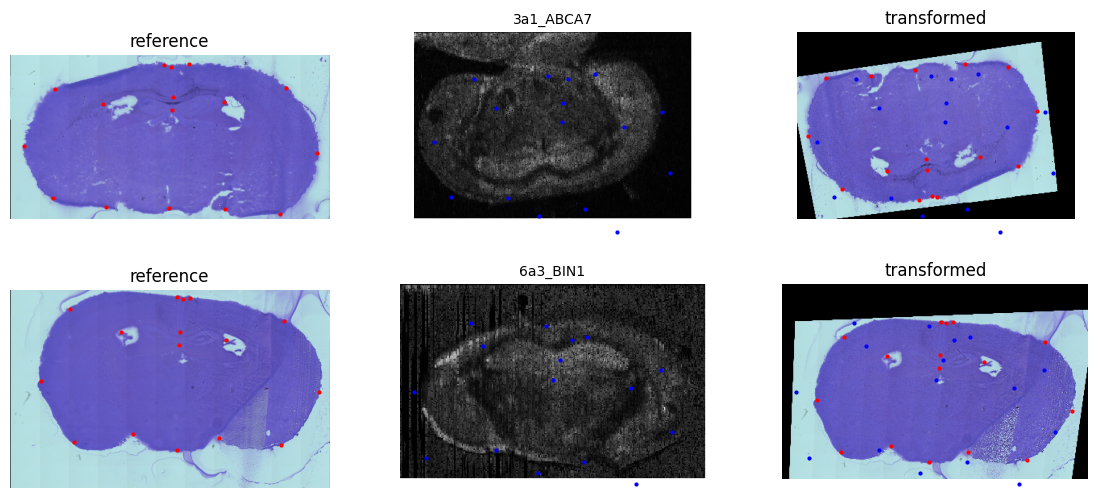

In [10]:
# STEP 3-  Plot images and landmarks, Visium, DESI, and transformed images + landmarks

nrow=2
import re
# plt.figure(figsize=(8, nrow*3))
plt.figure(figsize=(14,nrow*3))
for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed, ref_image) in enumerate(zip(samples,
                                                                                                               coord_sets, landmarks_transformed, reference_images,
                                                                                                                          images_transformed,query_images)):
    
    plt.subplot(nrow,3,3*i+1)
    plt.title('reference')
    plt.imshow(ref_image)
    plt.plot(query_landmarks.filter(regex='V').iloc[(2*i),:].values,
         query_landmarks.filter(regex='V').iloc[(2*i+1),:].values,'ro',markersize=2)
    plt.axis('off')

    # image to transform
    plt.subplot(nrow,3,3*i+2)
    plt.title(re.sub("","",sample), fontsize=10)
    plt.imshow(img)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
         reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    plt.axis('off')

    # transformed image
    plt.subplot(nrow,3,3*i+3)
    plt.title('transformed')
    plt.imshow(img_transformed)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
        reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    # plt.plot(query_landmarks.iloc[(2*i),1:n_features].values,query_landmarks.iloc[(2*i+1),1:n_features].values,'ro',markersize=2)
    plt.plot(pd.DataFrame(landmark_transformed).iloc[:,0],
             pd.DataFrame(landmark_transformed).iloc[:,1],'o',c="red",markersize=2)
    plt.axis('off')
    

#plt.savefig('DESI/DESI2/'+'Transformation_'+sign+'_V2.pdf', dpi =400)

In [11]:
# STEP 4 - Link each spot to a pixel in DESI space

# Load in spots and their coordinates
spots_coords = pd.read_csv('results/r_output/spots_coords_hi_res.csv')
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")
spots_coords.imagerow = spots_coords.imagerow / 1.0
spots_coords.imagecol = spots_coords.imagecol / 1.0

# Transform point into another space (in this case DESI image space)
def transform_row(list_input, mat):
    res = transform_points(np.array(list_input), mat)
    if len(res[0]) == 2:
        return (res[0][0], res[0][1])
    else:
        return (0, 0)

sorter = unique(query_landmarks.sample_ID)
print(sorter)
spots_coords["transformed_row"] = 1.0
spots_coords['transformed_col'] = 1.0

# For each spot's center coordinates, find its linked DESI pixel coordinates
for i in range(spots_coords.shape[0]):
    j = sorter.index(spots_coords.slice[i])
    name = sorter[j]
    mat = mats[j]
    res1, res2 = transform_row(list(spots_coords.loc[i, ['imagecol', 'imagerow']]), mat)
    spots_coords.loc[i, 'transformed_col'] = res1
    spots_coords.loc[i, 'transformed_row'] = res2

# Save result
spots_coords.to_csv('results/py_output/spots_coords_ion_pixels_' + sign + '.csv', index=False)



['ABCA7-3-a1-8', 'BIN1-6-a3-8']
